# Data Generation and Extraction


In [7]:
import matplotlib.pyplot as plt
import os
import re 
from pathlib import Path
import subprocess
import numpy as np

In [8]:
sizes = [1024, 2048, 4096, 8192, 16384, 32768]

In [9]:
def generate_data(part: str) -> None:
    # First create results directory and make partA
    os.makedirs(f"./{part}-results/", exist_ok=True)
    subprocess.run(["make", part])
    for sz in sizes:
        output_path = f"./{part}-results/{sz}.times"
        mode = "7"
        with open(output_path, "w") as f:
            subprocess.run([f"./bins/{part}.bin", str(sz), mode], stdout=f, check=True)
        print(f"Finished running for sz = {sz}")


In [10]:
def extract_res(part: str): 
    def extract_res_from_file(file_path: str):
        # There will be either 3 or 4 occurences of this pattern per file
        pattern = r"(\d+)\s*microseconds"
        try:
            with open(file_path, 'r') as f:
                content = f.read()
            matches = re.findall(pattern, content)
            results = [int(m) for m in matches]        
            return results
        except FileNotFoundError:
            print(f"Error: {file_path} not found.")
            return []
    configs = ["CPU","Full","Stream"]
    return_dict = {}
    for config in configs:
        return_dict[config] = {}
    for sz in sizes:
        file_path = f"./{part}-results/{sz}.times"
        res = extract_res_from_file(file_path)
        assert(len(res) == 3)
        # Coalesced, Naive, CUBLAS
        for i in range(len(res)):
            return_dict[configs[i]][sz] = res[i]
    return return_dict        

In [ ]:
generate_data("partA")
dictionary = extract_res("partA")

# Plotting

In [34]:
def plot_performance_data(data, save_path: str):
    # 1. Setup Data
    categories = list(data.keys())
    sizes = sorted(data[categories[0]].keys())
    
    x = np.arange(len(sizes))
    width = 0.25

    # 2. Styling
    colors = ['#003f5c', '#bc5090', '#ffa600', "#3ff000"]
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

    # Calculate the total width of all bars in a grou   
    total_group_width = len(categories) * width
    
    # Create the Bars
    for i, category in enumerate(categories):
        raw_values = [data[category][sz] for sz in sizes]
        # Convert microseconds to seconds
        heights = [v / 1e6 if v != -1 else 0 for v in raw_values]
        
        # CENTERED LOGIC:
        # Starting from the left edge of the group, move to the center of the i-th bar
        offset = (i * width) - (total_group_width / 2) + (width / 2)
        bar_pos = x + offset
        
        # Plot the bars
        bars = ax.bar(bar_pos, heights, width, label=category, color=colors[i % len(colors)], 
                      edgecolor='white', linewidth=0.8, alpha=0.9)

        # 4. Add "DNF" text for -1 values
        for j, val in enumerate(raw_values):
            if val == -1:
                # Placed slightly above 0 so it's visible
                ax.text(bar_pos[j], 0.01, 'DNF', ha='center', va='bottom', 
                        color='red', fontweight='bold', fontsize=10, rotation=90)

    # 5. Formatting and Labels
    ax.set_xlabel('Matrix Size (N x N)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Execution Time (seconds)', fontweight='bold', fontsize=12)
    ax.set_title('CUDA Matrix Multiplication: Performance Comparison', 
                 fontweight='bold', fontsize=16, pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(sizes)
    ax.legend(title="Implementation", frameon=True, shadow=True)

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

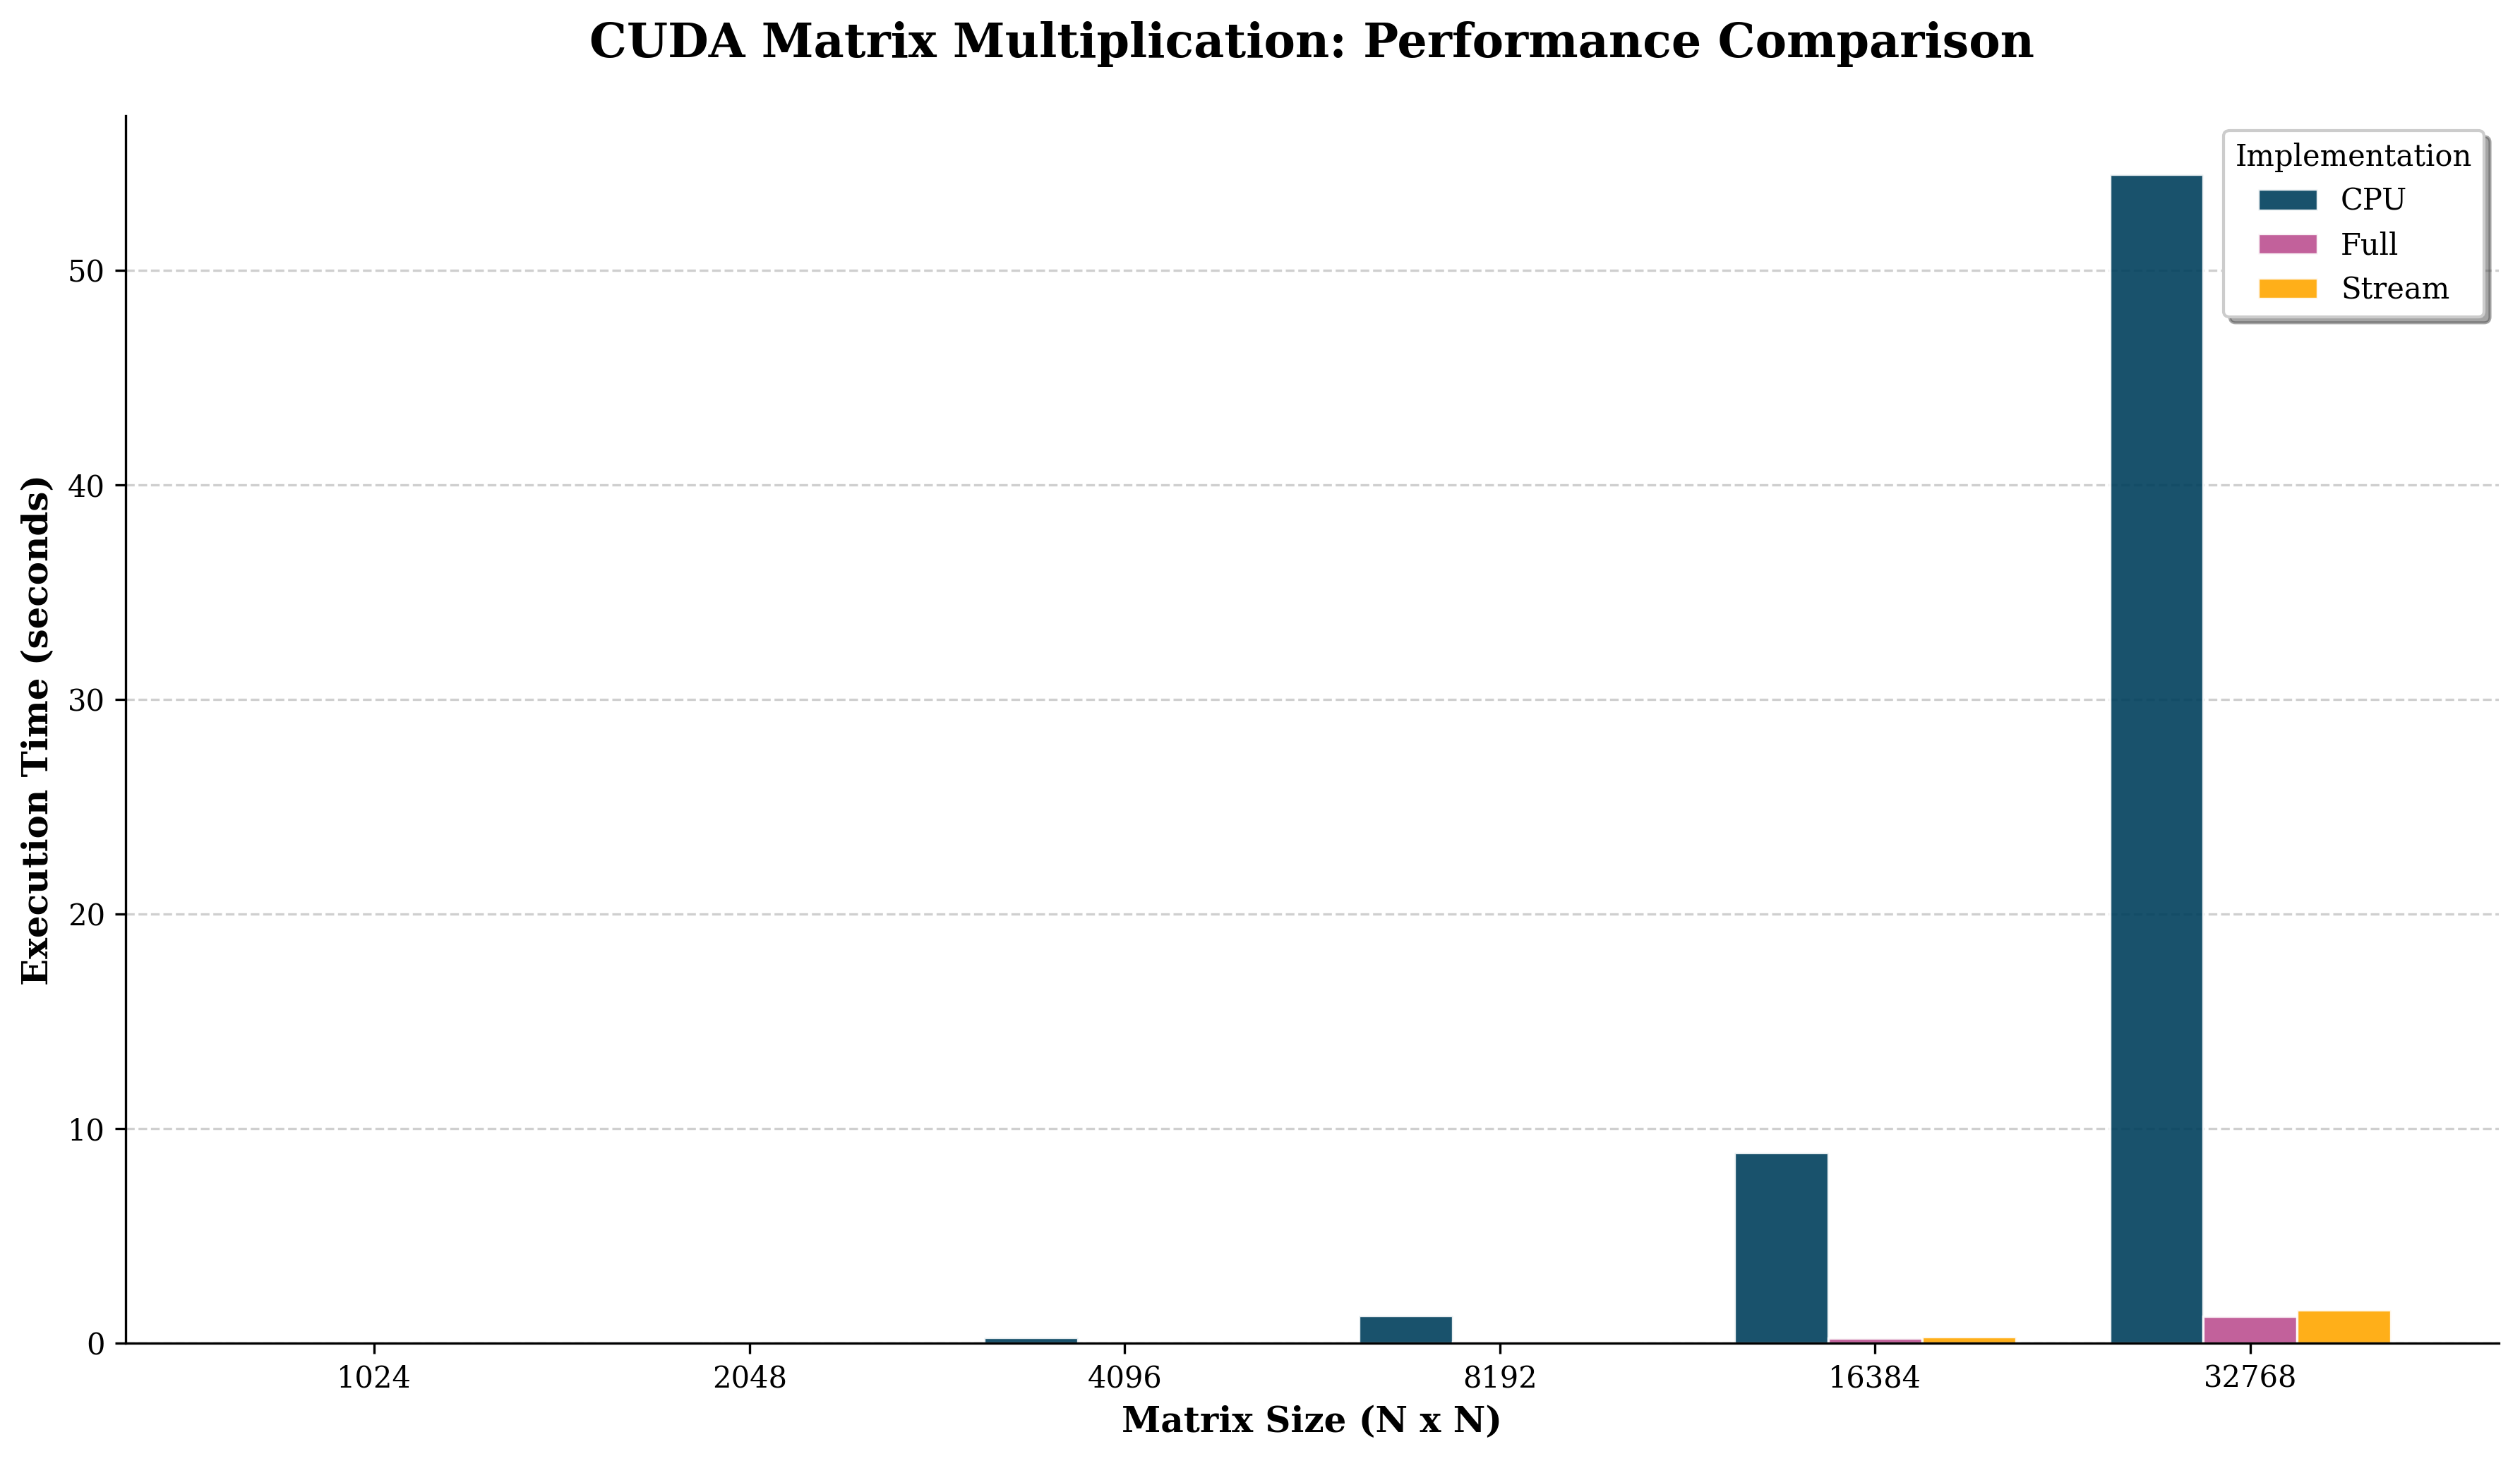

{'Full': {1024: 13135, 2048: 11371, 4096: 19594, 8192: 65849, 16384: 242891, 32768: 1256017}, 'Stream': {1024: 4240, 2048: 7419, 4096: 21167, 8192: 82158, 16384: 308225, 32768: 1562434}}


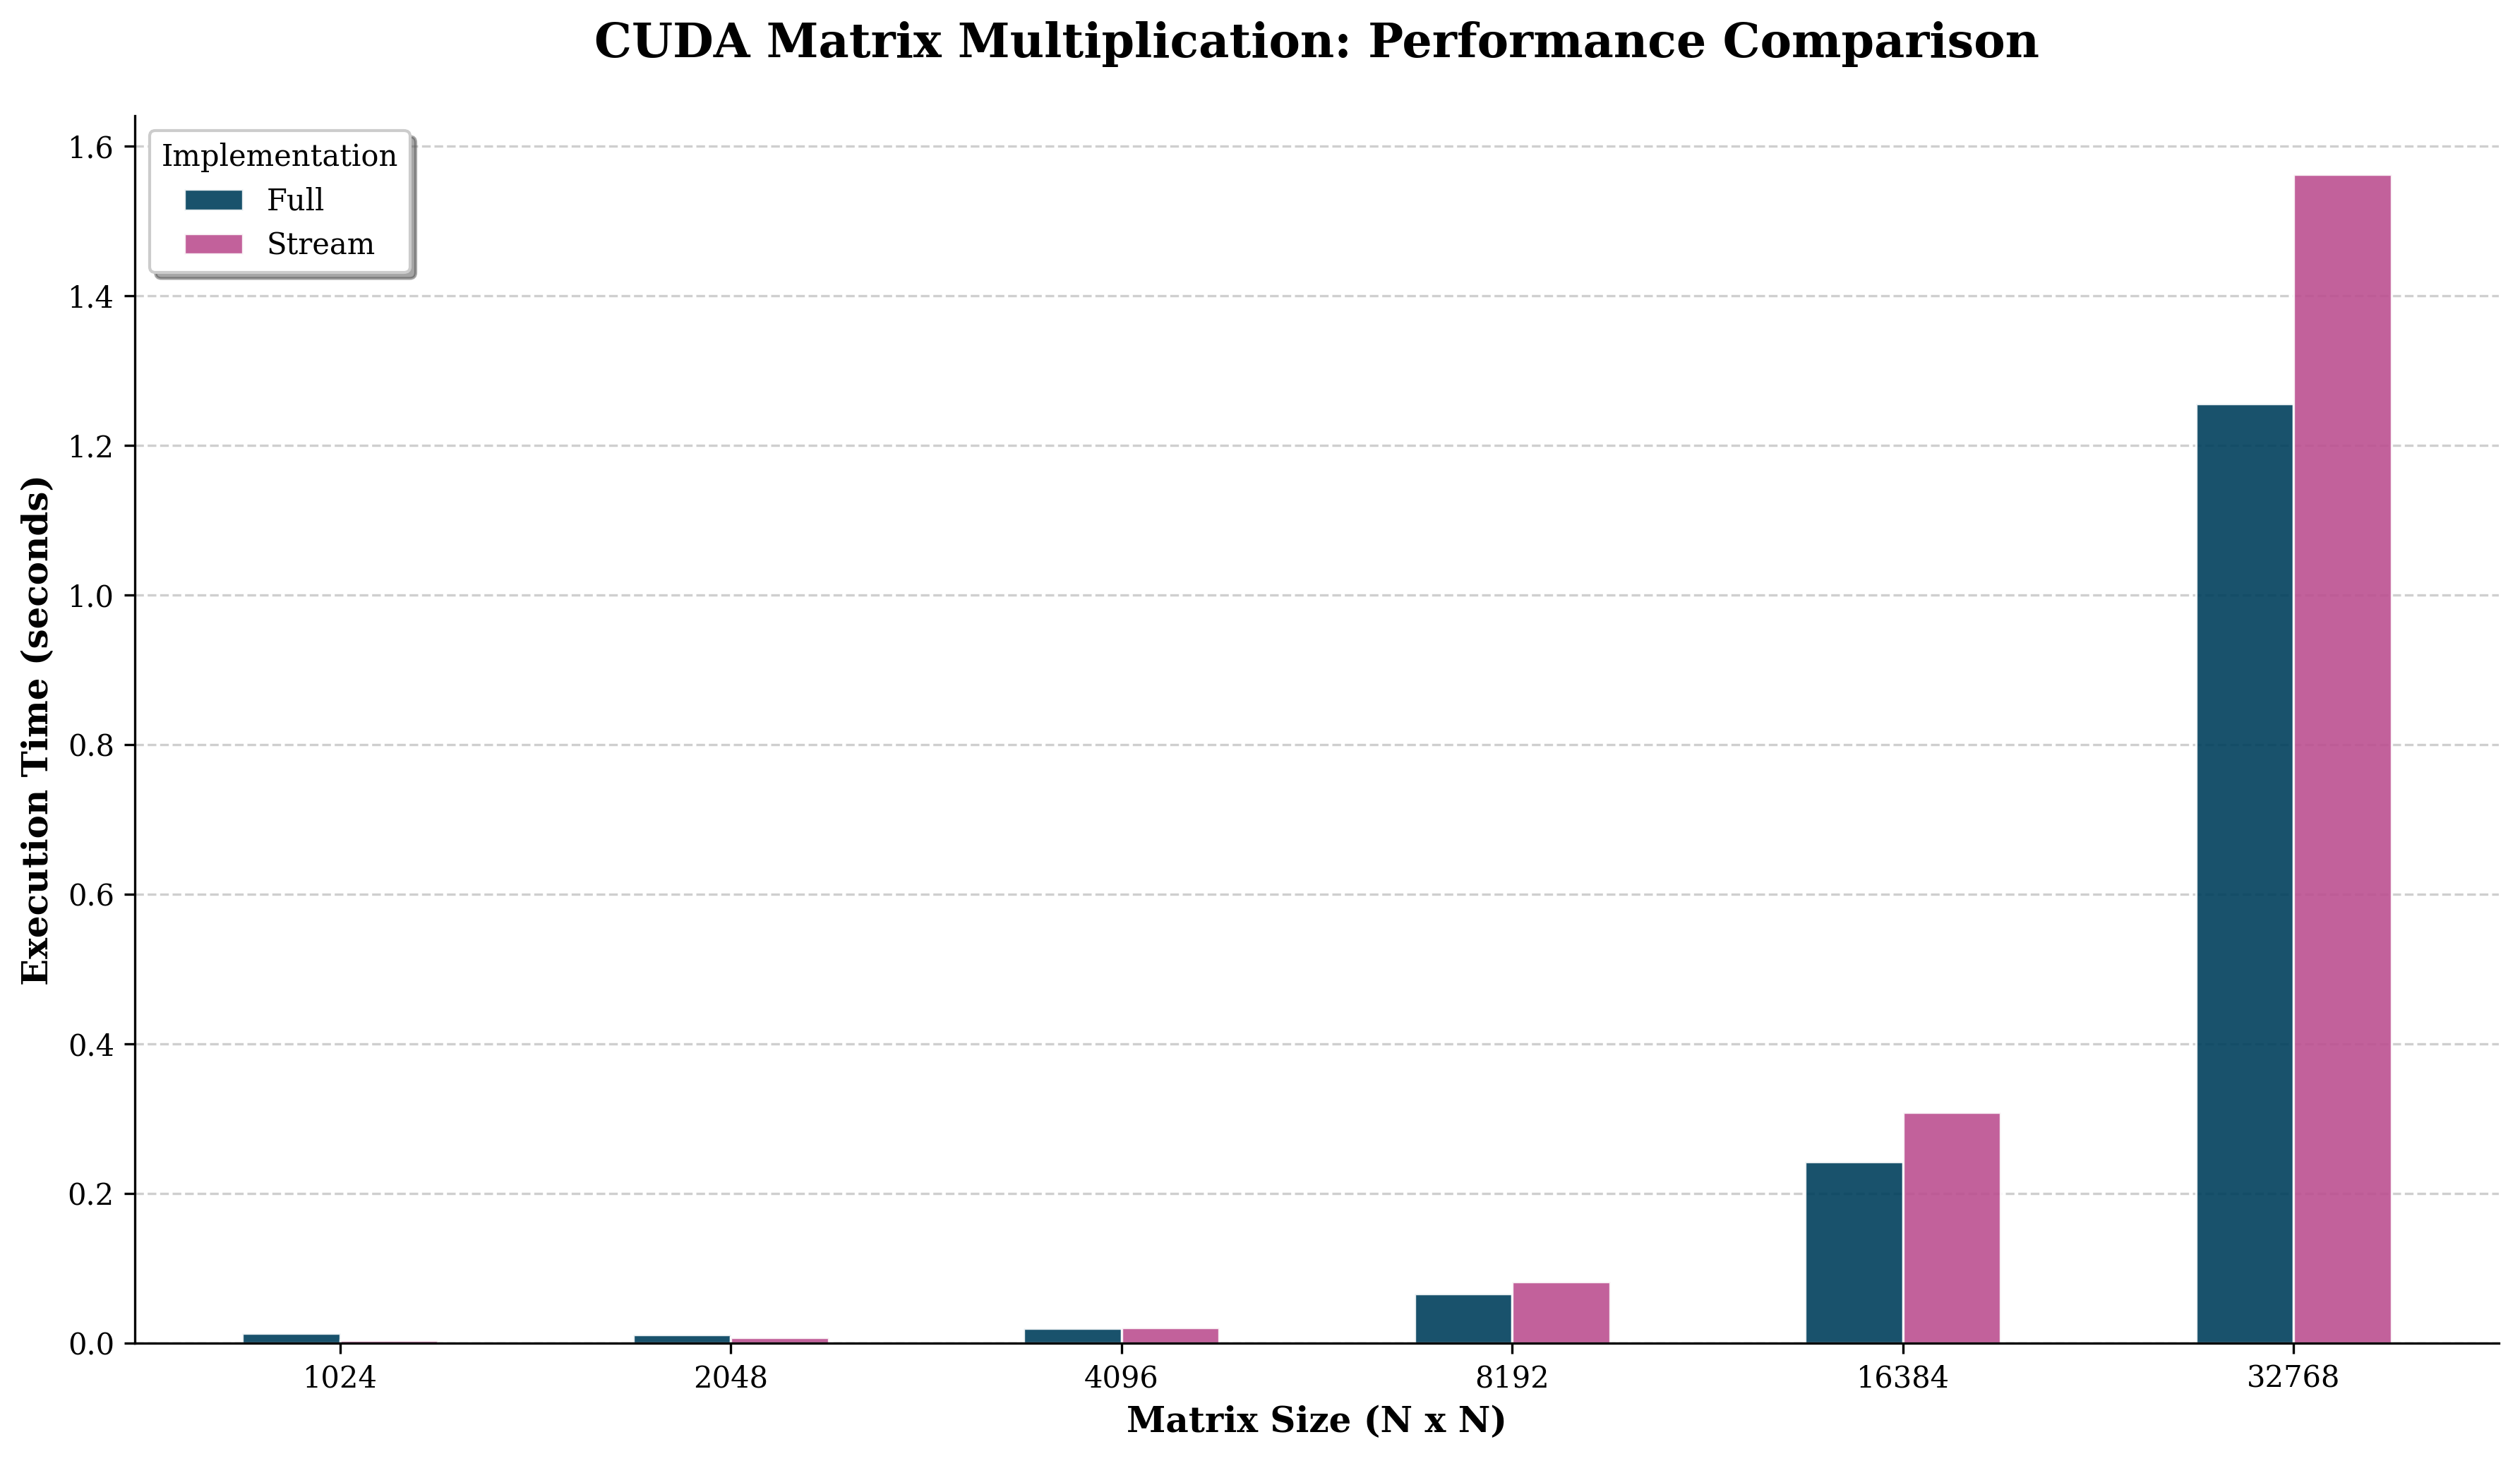

In [35]:
plot_performance_data(dictionary, "./plots/partA-times.pdf") 
new_dict = {}
for key in dictionary.keys():
    if key != "CPU":
        new_dict[key] = dictionary[key]
print(new_dict)
plot_performance_data(new_dict, "./plots/partA-times-nocpu.pdf")

# Pytorch NN

In [36]:
import torch
import torch.nn as nn
import time

In [37]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super(SimpleMLP, self).__init__()
        # PyTorch Linear layers perform xA^T. 
        # Since your math is W * x, we disable bias to match your logic.
        self.fc1 = nn.Linear(input_dim, input_dim, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(input_dim, input_dim, bias=False)

    def forward(self, x):
        # PyTorch expects (Batch, Features), so we transpose X 
        # or just ensure X is (BATCH_SIZE, N)
        y = self.relu(self.fc1(x))
        z = self.fc2(y)
        return z

In [40]:
def profile_torch():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 32
    times = {}
    for N in sizes:
        model = SimpleMLP(N).to(device)
        # Input X: (Batch, Features)
        x = torch.randn(BATCH_SIZE, N).to(device)
        for _ in range(10):
            _ = model(x)
        torch.cuda.synchronize()
        start_time = time.time()
        model(x)
        torch.cuda.synchronize()
        end_time = time.time()
        times[N] = (end_time - start_time) * 1000000
        print(f"Finished with N = {N}, time = {times[N]}")
    return times
        

Finished with N = 1024, time = 403.6426544189453
Finished with N = 2048, time = 1818.4185028076172
Finished with N = 4096, time = 15782.11784362793
Finished with N = 8192, time = 2618.074417114258
Finished with N = 16384, time = 9563.922882080078
Finished with N = 32768, time = 1281192.7795410156


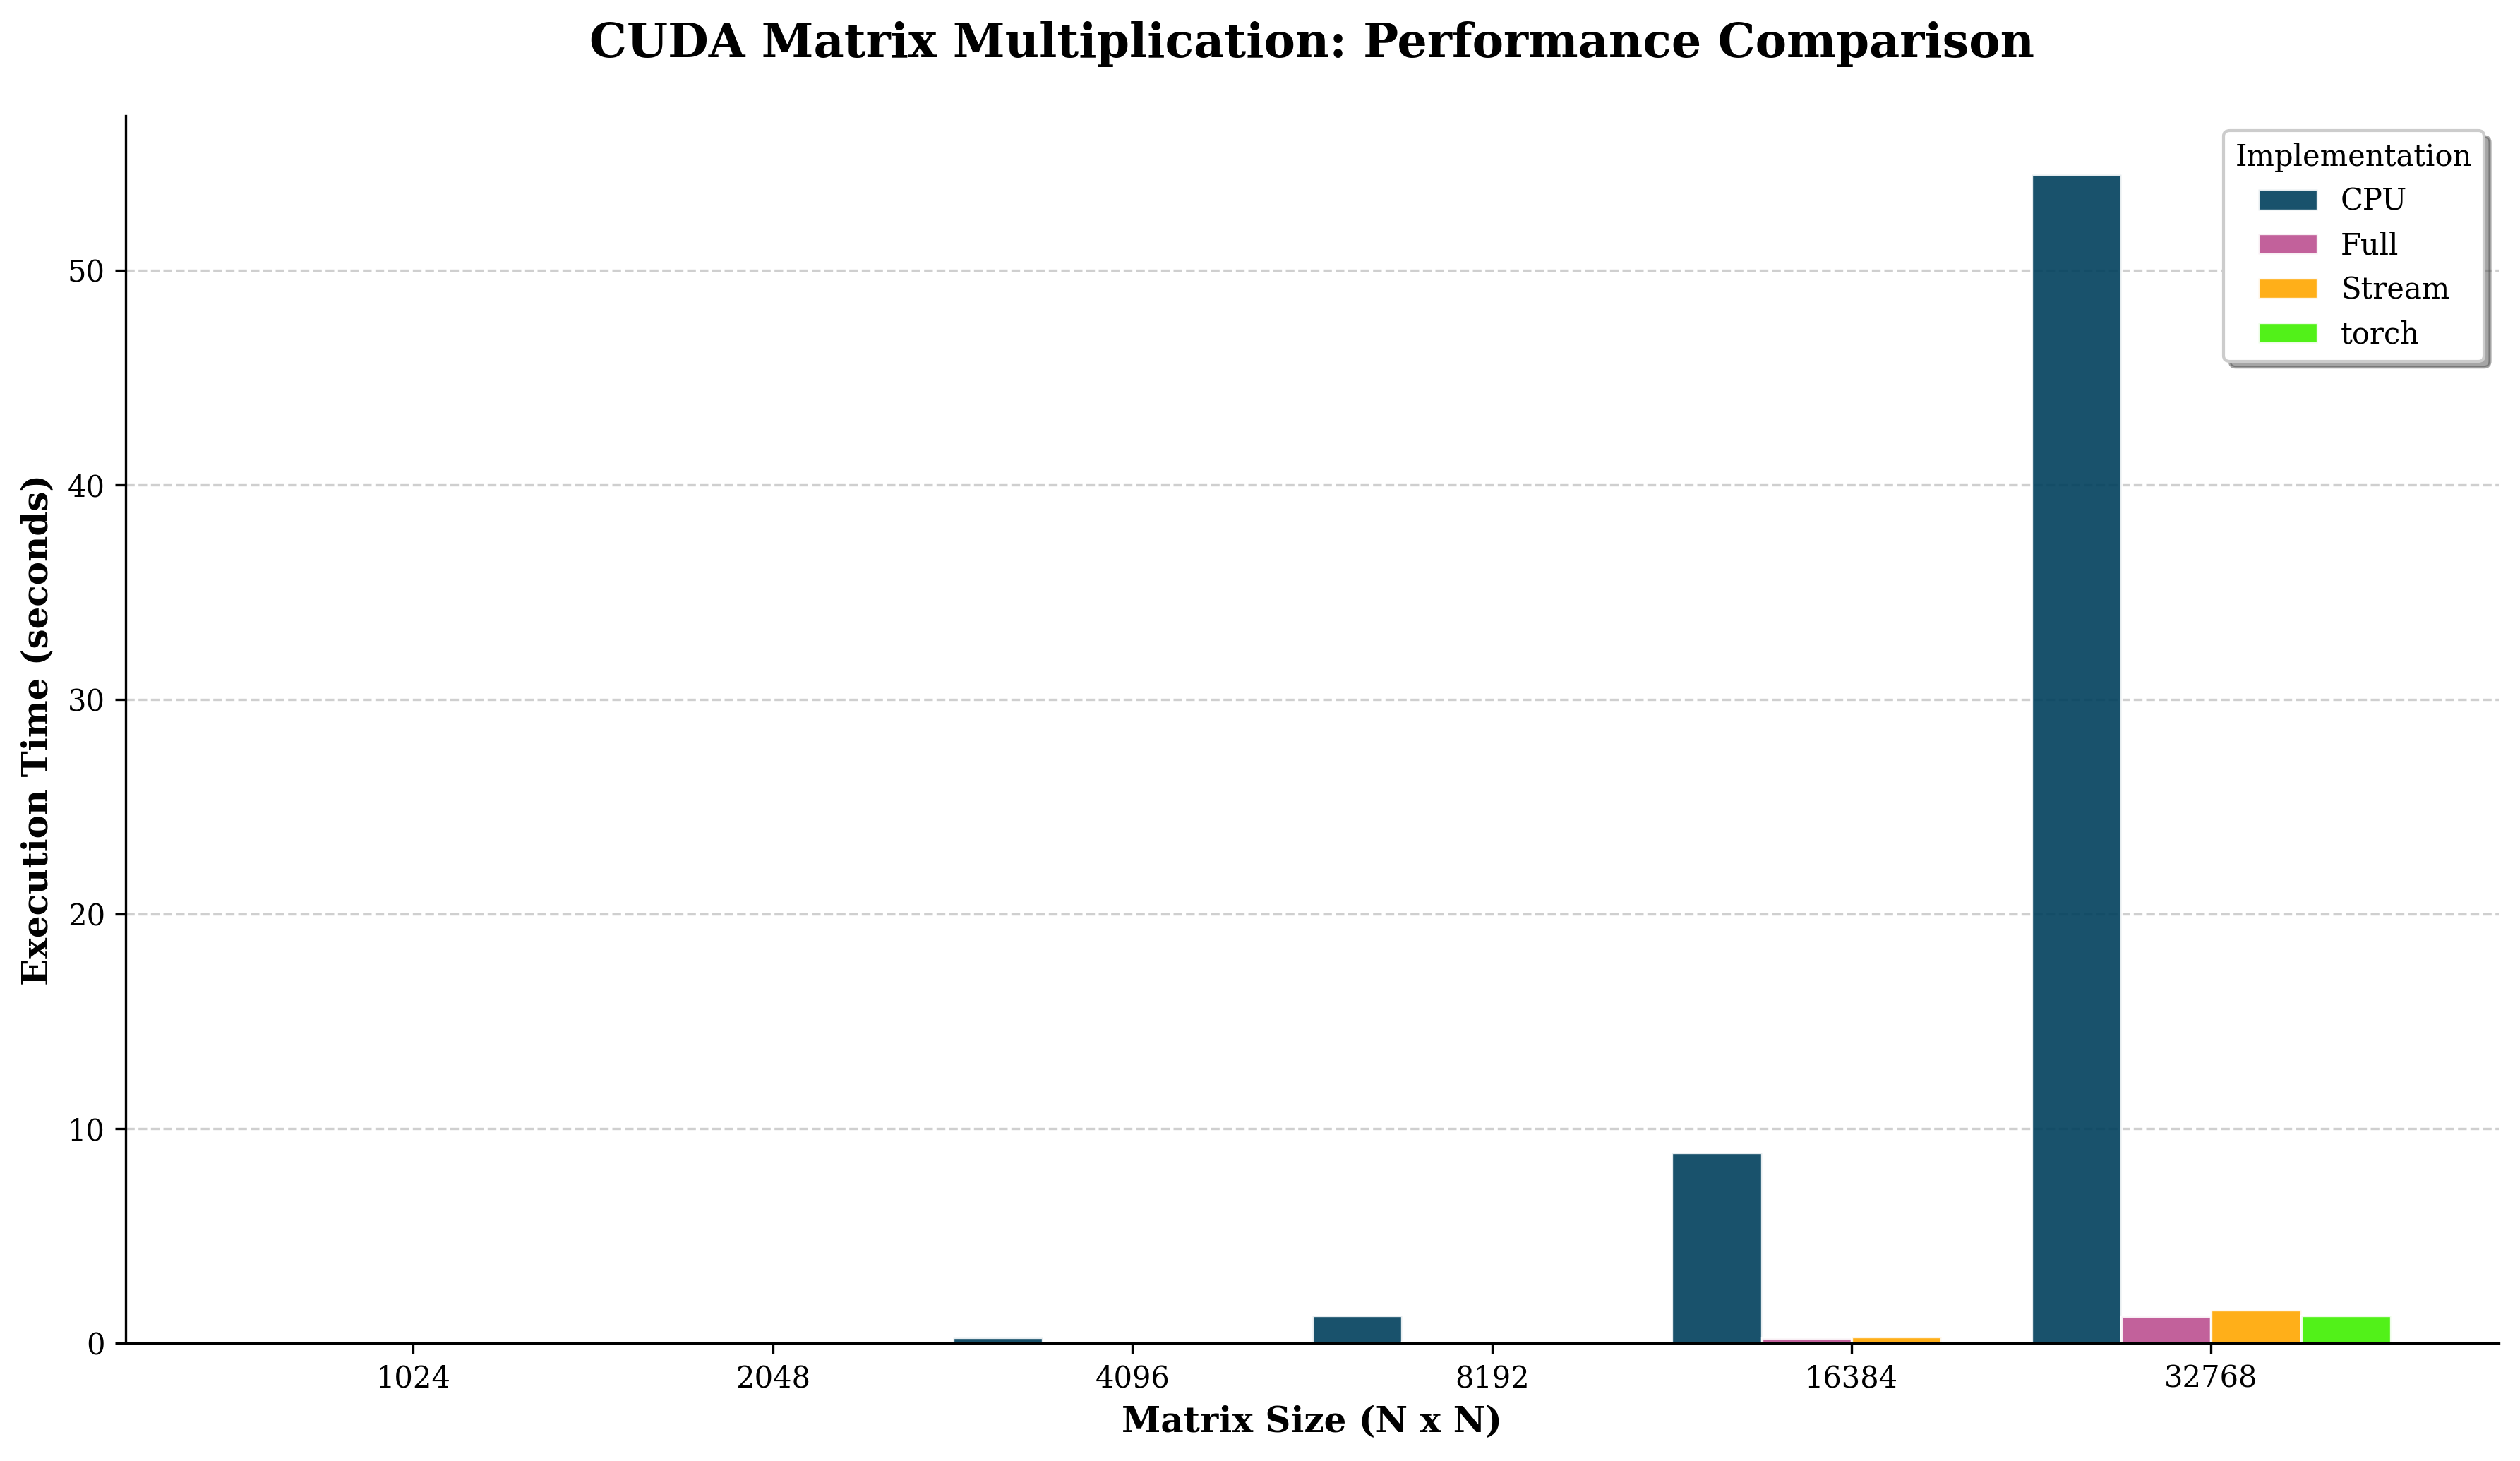

{'Full': {1024: 13135, 2048: 11371, 4096: 19594, 8192: 65849, 16384: 242891, 32768: 1256017}, 'Stream': {1024: 4240, 2048: 7419, 4096: 21167, 8192: 82158, 16384: 308225, 32768: 1562434}, 'torch': {1024: 403.6426544189453, 2048: 1818.4185028076172, 4096: 15782.11784362793, 8192: 2618.074417114258, 16384: 9563.922882080078, 32768: 1281192.7795410156}}


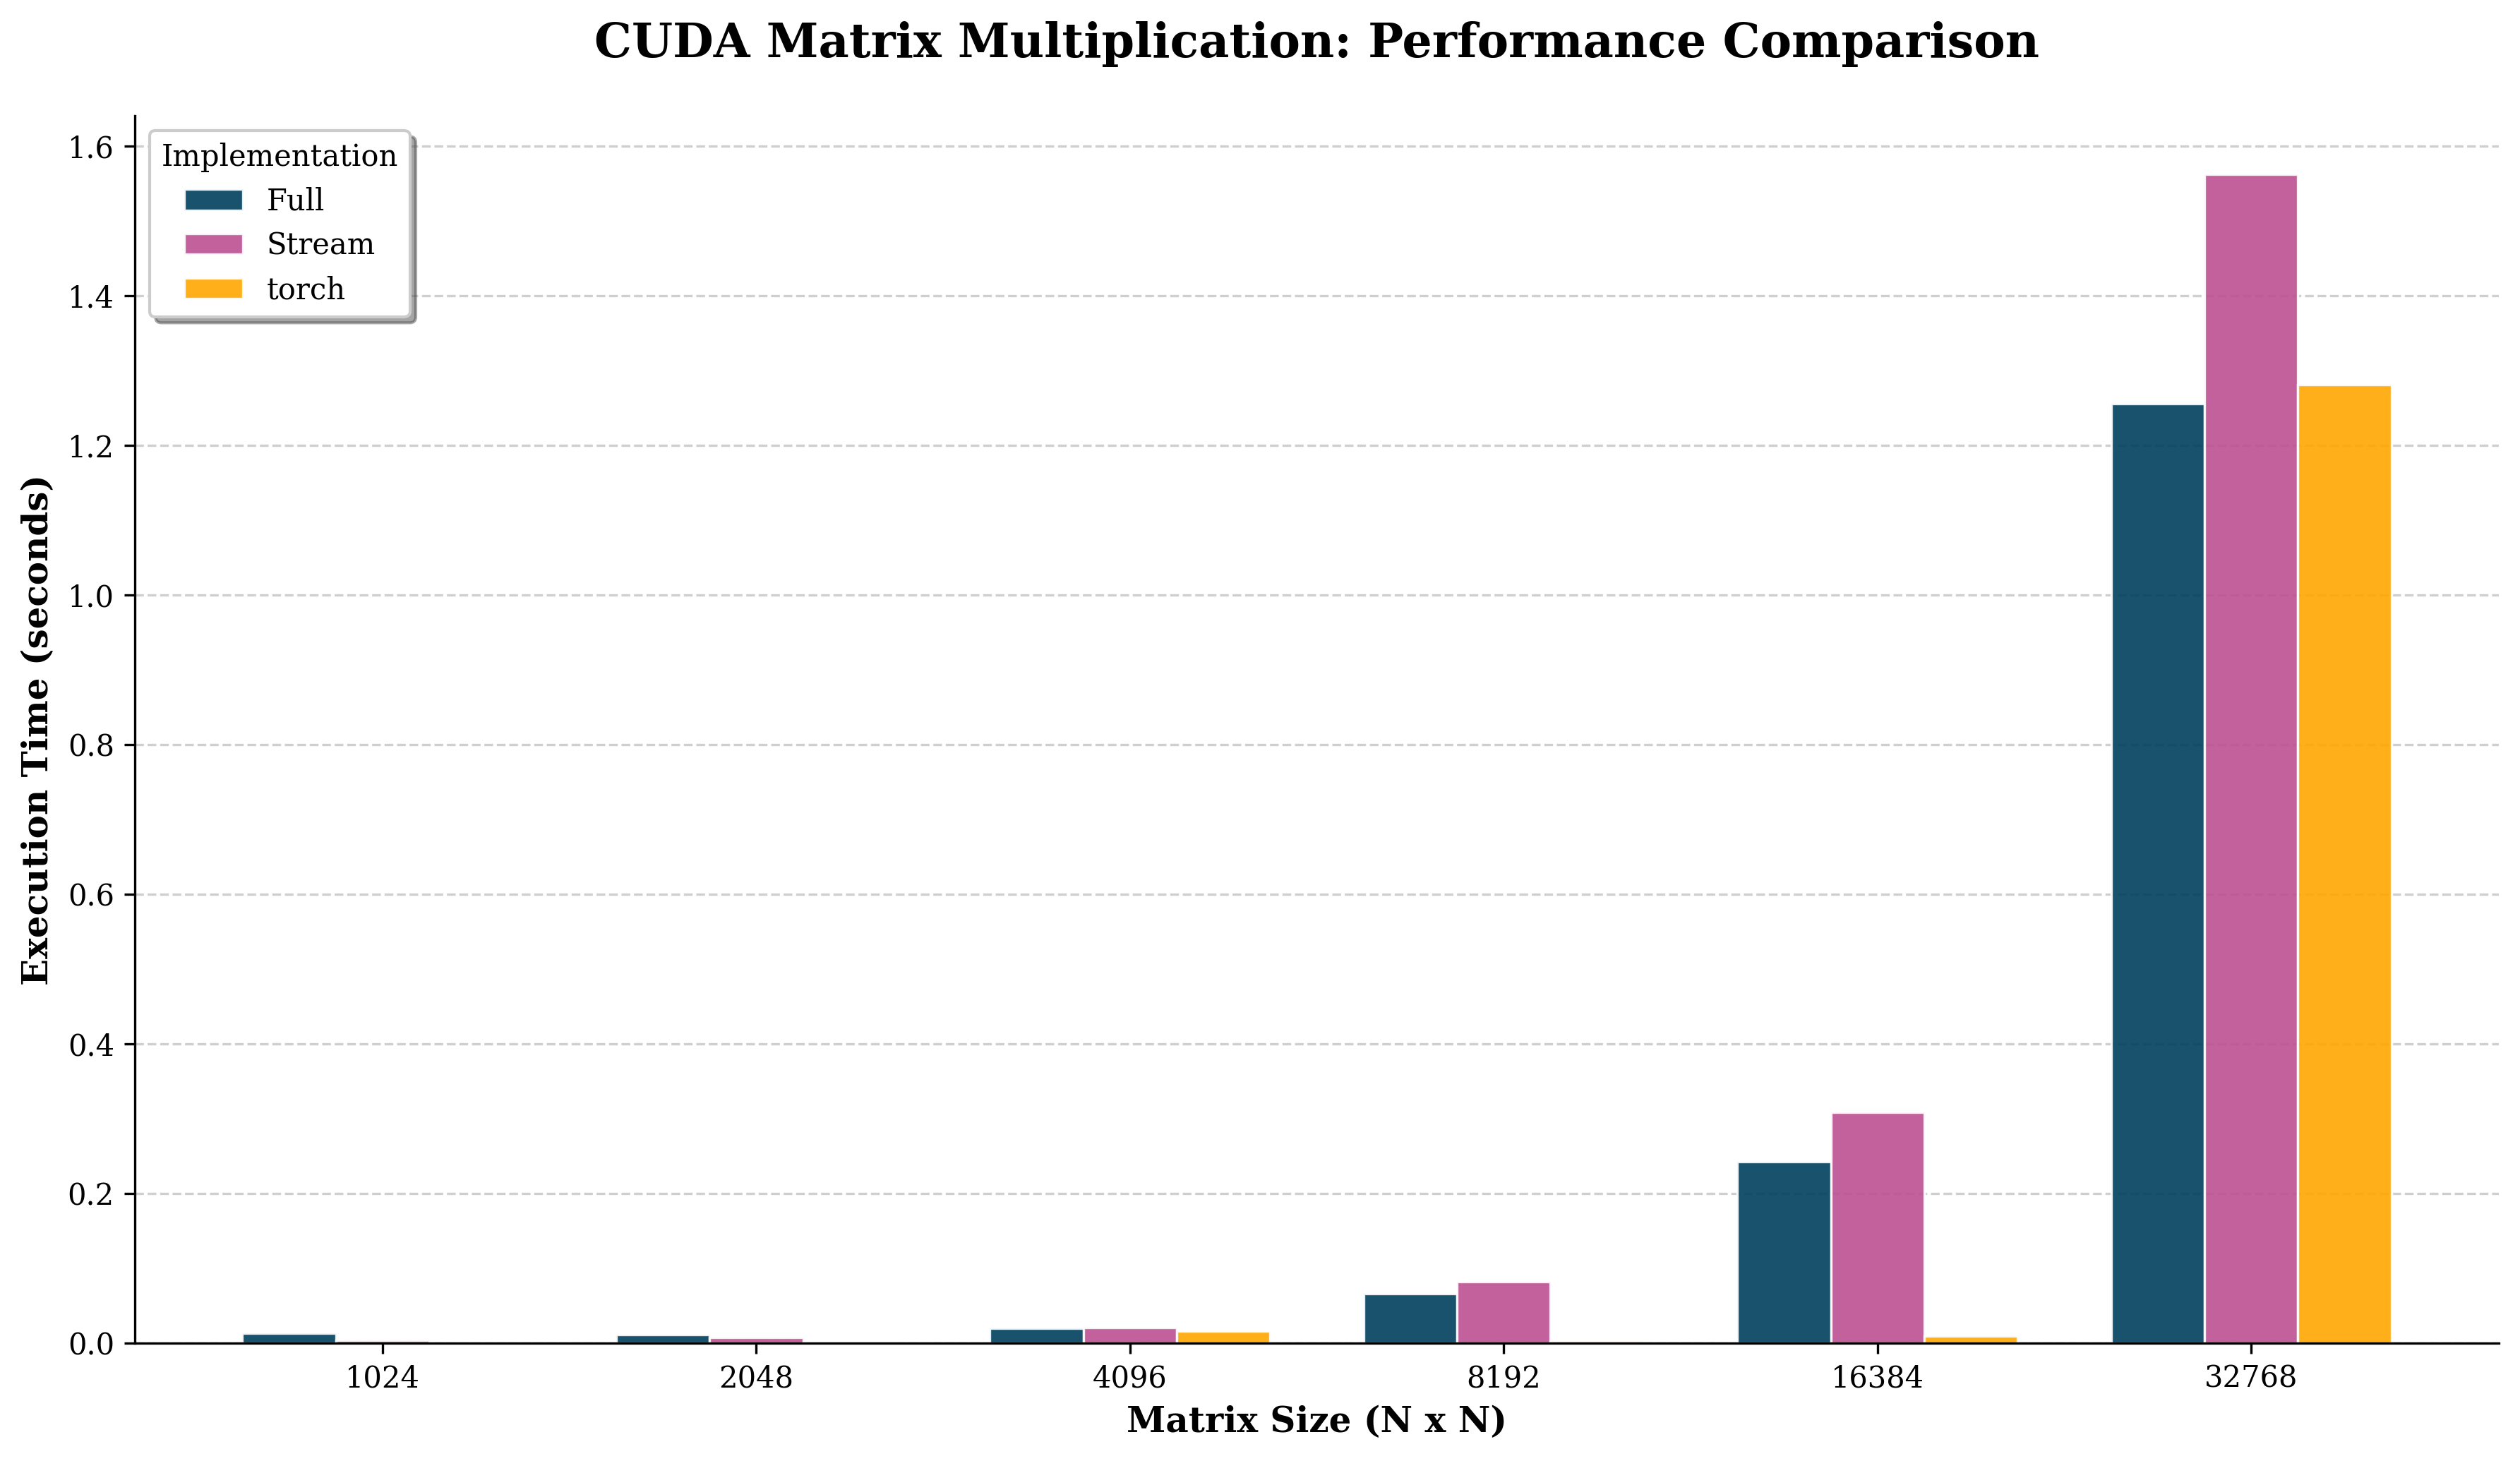

In [41]:
dictionary["torch"] = profile_torch()
plot_performance_data(dictionary, "./plots/partA-times-torch.pdf") 
new_dict = {}
for key in dictionary.keys():
    if key != "CPU":
        new_dict[key] = dictionary[key]
print(new_dict)
plot_performance_data(new_dict, "./plots/partA-times-torch-nocpu.pdf")